<img src="https://gsb.skku.edu/_res/en/img/common/logo_eng.png" alt="SKK Graduate School of Business Logo">

<center><font size="6">Team Project II: Tactical and Strategic Planning with Demand Forecast</font></center>
<p>
<center><font size="3">Business Forecast by Yanbo Wang</font></center>

# Business Background and Context  

**Company:** GreenWave Appliances  
**Industry:** Consumer Electronics (Home Appliances)  

**Business Context:**  
GreenWave Appliances manufactures energy-efficient home appliances (e.g., refrigerators, washing machines). The company faces challenges in aligning its **strategic investments** (e.g., R&D for AI-powered appliances), **strategic capacity adjustments** (e.g., factory expansions), **tactical  seasonal workforce planning**, and **risk mitigation** (e.g., supply chain shocks).  

- **Strategic Planning (Trend):** Societal shifts toward sustainability drive long-term demand for eco-friendly appliances.  
- **Cyclical Planning (Capacity):** Economic cycles (e.g., recessions, booms) impact mid-term demand for premium products.  
- **Seasonal Planning:** Demand spikes during holiday seasons (Q4) and summer (home renovations).  
- **Irregular Shocks:** Pandemics, tariffs, or supply chain disruptions cause short-term volatility.  

# Time Series Prediction Steps for Tactical & Strategic Planning with ARIMA  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

## Data Inspection

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/BF/team_project_2/demand_forecast_assignment.csv')
df.head()

,Date,Demand,Trend,Cyclical,Seasonal,Irregular
0,1990-01-01,92.983571,100.5,0.000000,-10.000000,2.483571
1,1990-02-01,103.218503,101.0,1.570079,1.339746,-0.691322
2,1990-03-01,120.194805,101.5,3.135854,12.320508,3.238443
3,1990-04-01,134.308183,102.0,4.693034,20.000000,7.615149
4,1990-05-01,129.887092,102.5,6.237351,22.320508,-1.170767


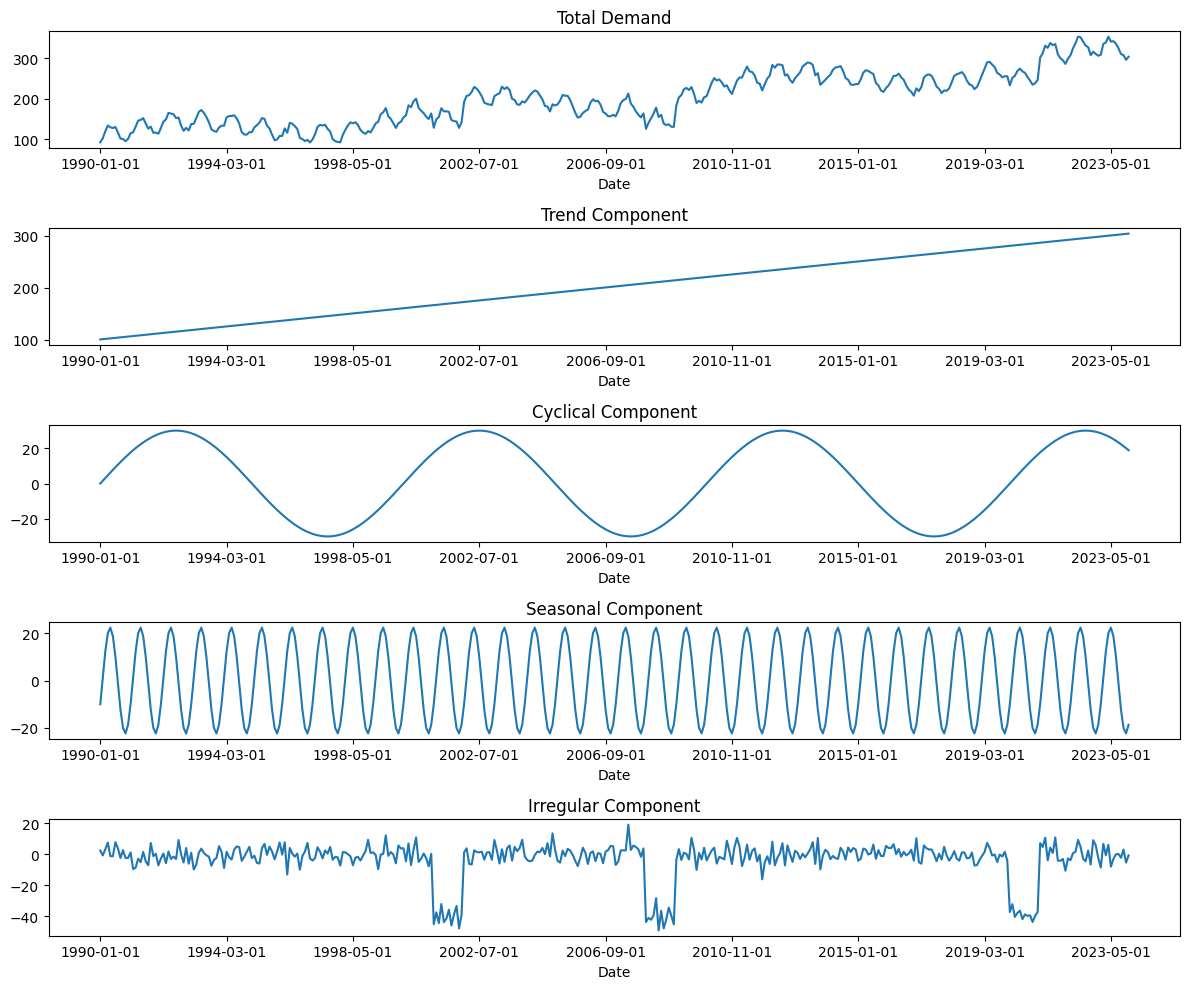

In [ ]:
df=df.set_index("Date")

# Plot components
fig, axes = plt.subplots(5, 1, figsize=(12, 10))
df["Demand"].plot(ax=axes[0], title="Total Demand")
df["Trend"].plot(ax=axes[1], title="Trend Component")
df["Cyclical"].plot(ax=axes[2], title="Cyclical Component")
df["Seasonal"].plot(ax=axes[3], title="Seasonal Component")
df["Irregular"].plot(ax=axes[4], title="Irregular Component")
plt.tight_layout()
plt.show()

## Step 1: Decompose Time Series  

In [ ]:
decomposition = seasonal_decompose(df["Demand"], model="additive", period=12)

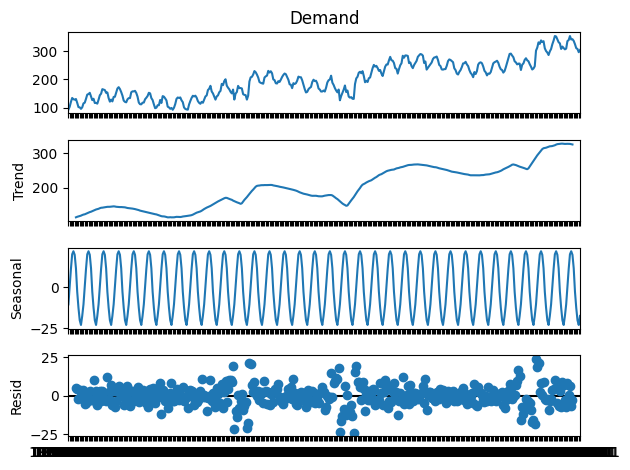

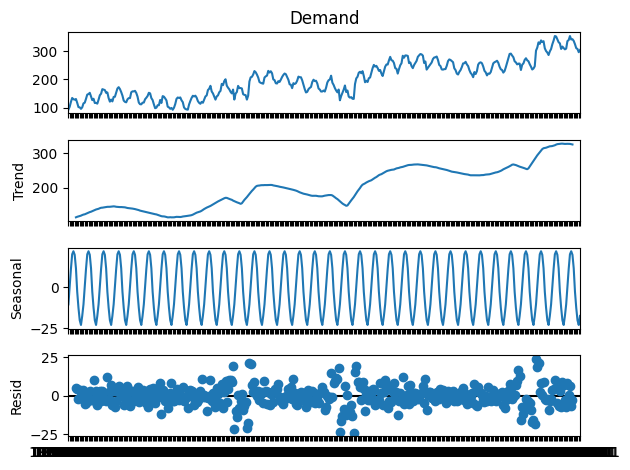

In [ ]:
decomposition.plot()

## Step 2: Model Trend & Cyclical Components (Strategic Planning)  

**ARIMA Model:** Fit ARIMA to the **trend-cycle** (detrended data) for long-term forecasts.

<Axes: xlabel='Date'>

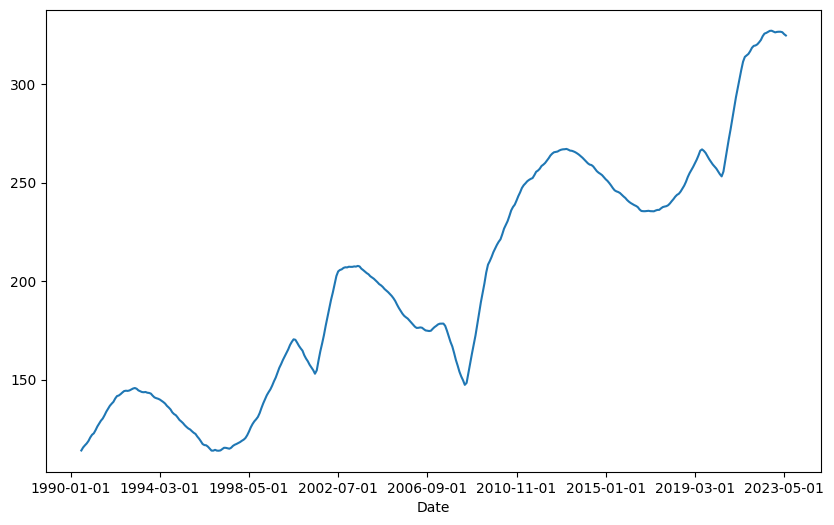

In [ ]:
decomposition.trend.plot(figsize=(10, 6))

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


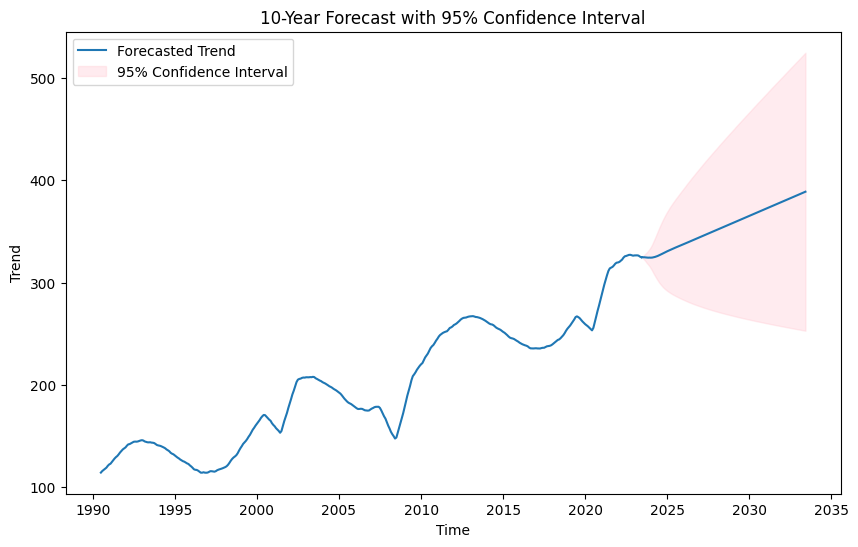

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Assuming decomposition.trend is your time series data with a DatetimeIndex
model = ARIMA(decomposition.trend.dropna(), order=(10,2,10))  # Example parameters
results = model.fit()

# Forecast with confidence intervals
forecast_steps = 120  # 10-year forecast
forecast = results.get_forecast(steps=forecast_steps)
forecast_trend = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

# Combine the original trend and the forecasted trend
forecast_trend_combined = pd.concat([decomposition.trend, forecast_trend], axis=0)

# Ensure the index is a DatetimeIndex (if not already)
forecast_trend_combined.index = pd.to_datetime(forecast_trend_combined.index)
confidence_intervals.index = pd.to_datetime(confidence_intervals.index)

# Plot the original trend, forecasted trend, and confidence intervals
plt.figure(figsize=(10, 6))
plt.plot(forecast_trend_combined.index, forecast_trend_combined, label='Forecasted Trend')
plt.fill_between(confidence_intervals.index,
                 confidence_intervals.iloc[:, 0],
                 confidence_intervals.iloc[:, 1],
                 color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title('10-Year Forecast with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Trend')
plt.legend()
plt.show()

**Potential Strategic Actions:**  
  - Invest in R&D for AI appliances (align with upward trend)?
> The upward trend indicates growing demand for energy-efficient appliances. By investing in R&D for AI technologies, we can optimize energy consumption, enhance product performance, and strengthen our market position. This aligns with the long-term sustainability trend.

  - Plan factory expansions if the cyclical component predicts a boom?
> For factory expansions, the cyclical component suggests that we should increase capacity during potential booms. However, we need to carefully analyze past demand fluctuations, our financing options, and potential downside risks to determine the appropriate scale of expansion.

## Step 3: Model Seasonality (Tactical Planning)

SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors) is a powerful statistical model used for time series forecasting. It extends the ARIMA model by incorporating seasonality and exogenous variables (external factors). SARIMAX is particularly useful for time series data that exhibit trends, seasonality, and dependencies on external variables.

Seasonal Parameters: (P, D, Q, s)

P: Seasonal autoregressive order.

D: Seasonal differencing order.

Q: Seasonal moving average order.

s: Seasonal period (e.g., s=12 for monthly data with yearly seasonality).

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


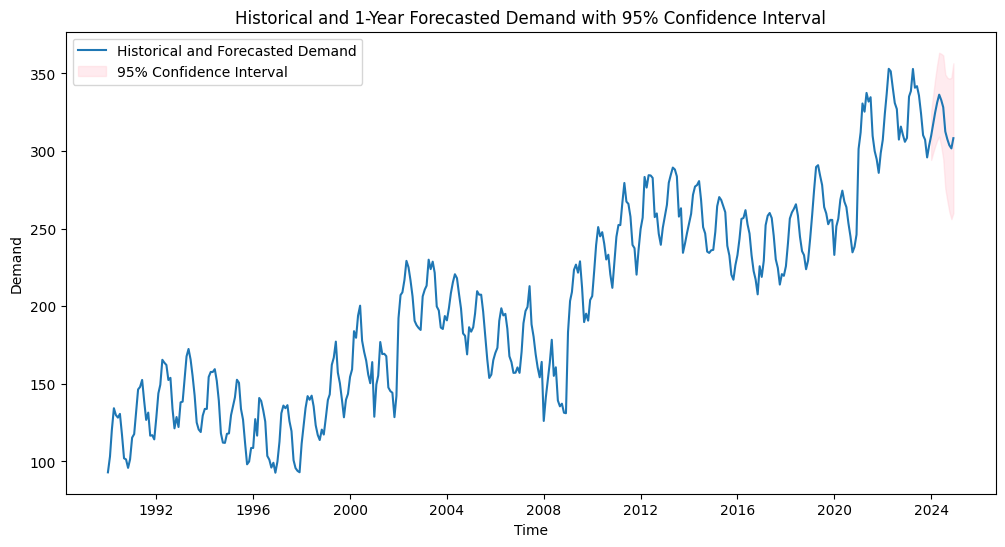

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX

# (모델 학습 부분은 동일)
seasonal_model = SARIMAX(df["Demand"], order=(10,2,10), seasonal_order=(1,1,1,12))
seasonal_results = seasonal_model.fit()

# 예측
forecast_steps = 12
forecast = seasonal_results.get_forecast(steps=forecast_steps)
forecast_seasonal = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

historical_demand = df["Demand"]
forecast_seasonal_combined = pd.concat([historical_demand, forecast_seasonal], axis=0)

forecast_seasonal_combined.index = pd.to_datetime(forecast_seasonal_combined.index)
confidence_intervals.index = pd.to_datetime(confidence_intervals.index)

plt.figure(figsize=(12, 6))
plt.plot(forecast_seasonal_combined.index, forecast_seasonal_combined, label='Historical and Forecasted Demand')
plt.fill_between(confidence_intervals.index,
                 confidence_intervals.iloc[:, 0],
                 confidence_intervals.iloc[:, 1],
                 color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title('Historical and 1-Year Forecasted Demand with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Demand')
plt.legend()
plt.show()


**Potential Tactical Actions:**  
  - Adjust inventory levels ahead of Q4?
  - Hire temporary workers for summer production?

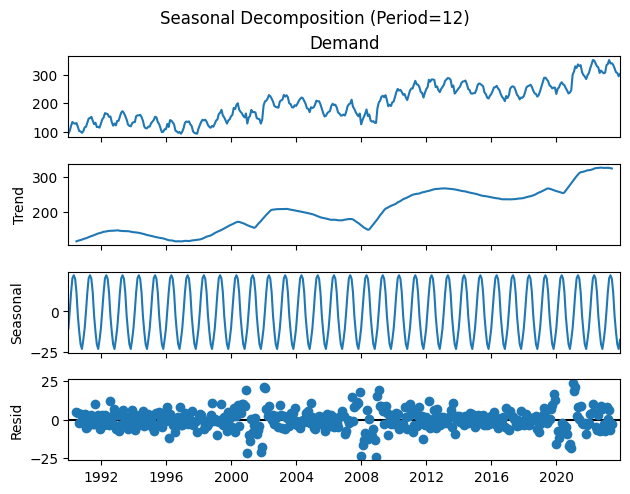

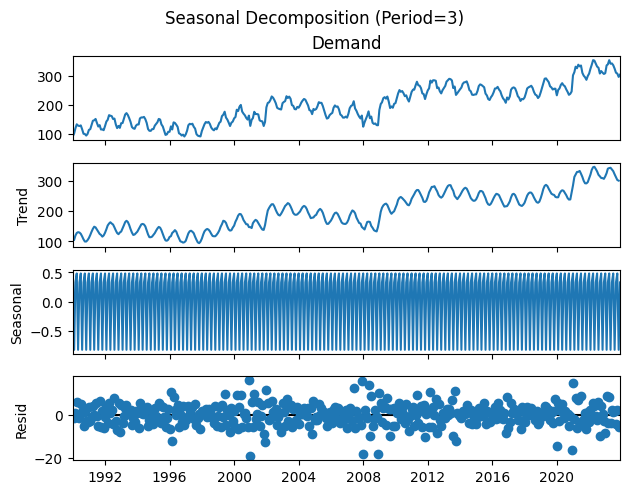

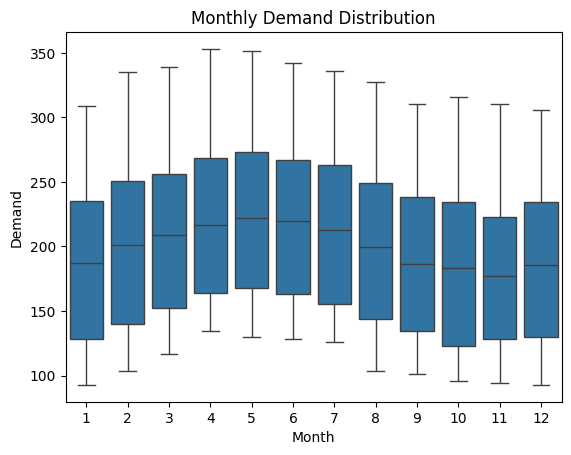

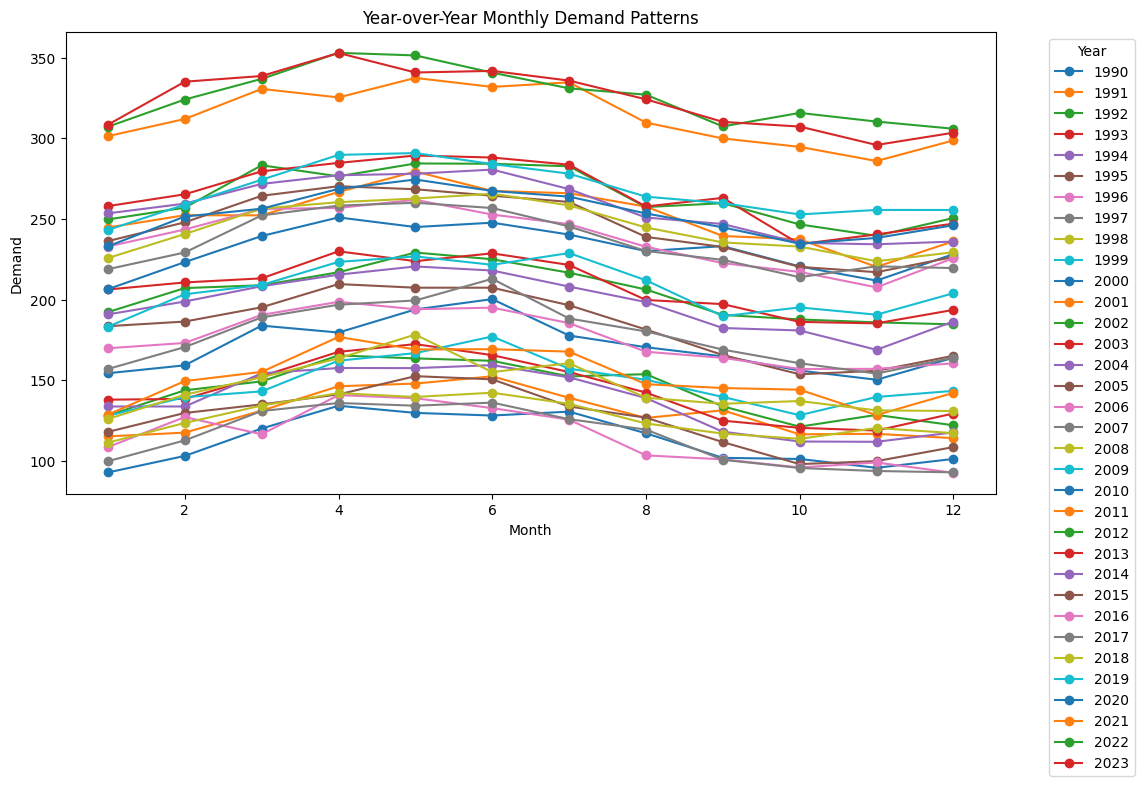

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. 데이터 준비: 인덱스가 문자열 등이라면 DatetimeIndex로 변환
df.index = pd.to_datetime(df.index)

# 2. 시계열 분해 (Period=12: 연 단위 계절성 확인)
decomposition = seasonal_decompose(df["Demand"], model='additive', period=12)
decomposition.plot()
plt.suptitle('Seasonal Decomposition (Period=12)', y=1.02)
plt.show()

# 2-1. (옵션) 시계열 분해 (Period=3: 분기 주기 확인)
decomposition_q = seasonal_decompose(df["Demand"], model='additive', period=3)
decomposition_q.plot()
plt.suptitle('Seasonal Decomposition (Period=3)', y=1.02)
plt.show()

# 3. 월별 박스플롯: 각 달의 수요 분포 확인 (월별 계절성 확인)
df_reset = df.reset_index()      # 인덱스를 'Date' 컬럼으로 변환
df_reset.rename(columns={'index': 'Date'}, inplace=True)
df_reset['Month'] = df_reset['Date'].dt.month

sns.boxplot(x="Month", y="Demand", data=df_reset)
plt.title("Monthly Demand Distribution")
plt.xlabel("Month")
plt.ylabel("Demand")
plt.show()

# 4. 연도별 월별 오버레이 플롯: 여러 해의 월별 패턴을 겹쳐서 확인
df_reset['Year'] = df_reset['Date'].dt.year

plt.figure(figsize=(12, 6))
for year, group in df_reset.groupby('Year'):
    plt.plot(group['Date'].dt.month, group['Demand'], marker='o', label=str(year))
plt.xlabel('Month')
plt.ylabel('Demand')
plt.title('Year-over-Year Monthly Demand Patterns')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


**Interpretation**

Over the past 30 years, our monthly demand data clearly shows a steady upward trend, indicating that the market for energy-efficient appliances is continuously growing. This long-term increase not only signals a rising demand but also aligns with the sustainability trend in the industry. In light of this, investing in R&D for AI technologies becomes especially attractive. Such investments can help us optimize energy consumption, improve product performance, and ultimately strengthen our market position.

At the same time, our analysis reveals a consistent annual seasonal pattern. Demand typically spikes between May and August, while it tends to be lower in January and February. Although we don't see a strong pattern on a quarterly (3-month) basis, the clear 12-month cycle suggests that our operational strategies—such as production, marketing, and inventory management—should be planned on an annual basis. For example, we can prepare for the summer peak by bolstering inventory and staffing, and then ease our inventory levels during the slower early months.

Additionally, the cyclical component of the data indicates that there are periods of potential booms. This suggests that we might consider expanding our production capacity when the market is in a high-demand phase. However, any decision on factory expansion should be made after a careful review of past demand fluctuations, our available financing options, and the potential risks involved.

In summary, the long-term upward trend and clear annual seasonality support a dual strategy: invest in advanced technologies like AI to maintain competitiveness and meet growing demand, and strategically plan for capacity increases during market booms while managing risks through diversified supply chains and adequate safety stocks.

## Step 4: Analyze Irregular Component (Risk Management)

The irregular component represents unexpected shocks to demand, such as pandemics, economic crises, or supply chain disruptions. Analyzing this component helps businesses prepare for uncertainty by sizing safety stock, adjusting inventory policies, and creating contingency plans.

Volatility (Standard Deviation of Irregular Component): 6.69


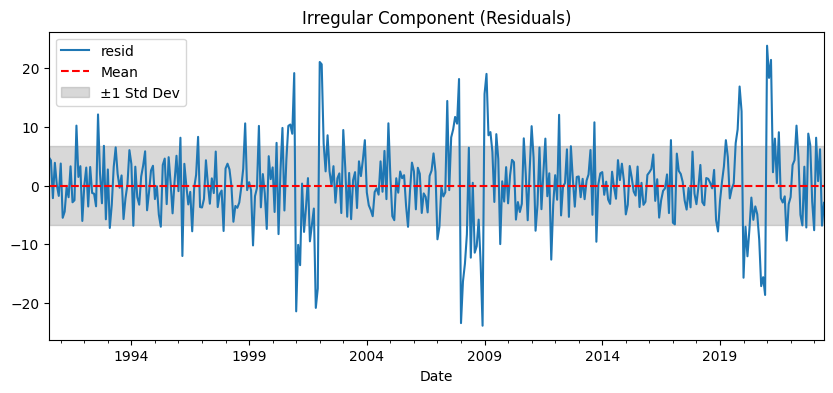

Extreme Shocks (Beyond 2 Standard Deviations):
Date
2000-12-01    19.170841
2001-01-01   -21.429657
2001-03-01   -13.560303
2001-11-01   -20.840599
2001-12-01   -17.529411
2002-01-01    21.061956
2002-02-01    20.666379
2007-06-01    14.422682
2007-12-01    18.162664
2008-01-01   -23.436515
2008-02-01   -16.333962
2008-12-01   -23.879936
2009-01-01    15.614092
2009-02-01    19.036974
2019-11-01    16.887044
2020-01-01   -15.700057
2020-10-01   -17.130987
2020-11-01   -15.609048
2020-12-01   -18.637610
2021-01-01    23.836381
2021-02-01    18.357820
2021-03-01    21.421574
Name: resid, dtype: float64


In [ ]:
# Extract irregular component
irregular_component = decomposition.resid.dropna()

# Calculate volatility (standard deviation of residuals)
volatility = irregular_component.std()
print(f"Volatility (Standard Deviation of Irregular Component): {volatility:.2f}")

# Plot irregular component with shocks highlighted
plt.figure(figsize=(10, 4))
irregular_component.plot(title="Irregular Component (Residuals)")
plt.axhline(y=0, color="red", linestyle="--", label="Mean")
plt.fill_between(irregular_component.index, -volatility, volatility, color="gray", alpha=0.3, label="±1 Std Dev")
plt.legend()
plt.show()

# Identify extreme shocks (e.g., beyond 2 standard deviations)
shocks = irregular_component[np.abs(irregular_component) > 2 * volatility]
print("Extreme Shocks (Beyond 2 Standard Deviations):")
print(shocks)

 1. **Volatility Measurement:**  
   - The standard deviation of the irregular component quantifies demand volatility. For example, if the volatility is 10 units, demand can fluctuate by ±10 units due to random shocks.  
   - **Action:** Use this value to determine safety stock levels. For instance, if the lead time is 1 month, safety stock = `Z * volatility * sqrt(lead time)`, where `Z` is the desired service level (e.g., 1.65 for 95% service level).  

2. **Extreme Shocks:**  
   - Shocks beyond 2 standard deviations (e.g., -40 units during 2008 or 2020) represent significant disruptions.  
   - **Potential Action:**  
     - **Inventory Buffer:** Maintain additional inventory during periods of high uncertainty (e.g., geopolitical tensions, pandemic risks)?  
     - **Supply Chain Diversification:** Build relationships with multiple suppliers to mitigate risks of single-supplier disruptions?
     - **Scenario Planning:** Simulate extreme scenarios (e.g., 20% demand drop) and develop contingency plans (e.g., temporary factory shutdowns, workforce adjustments)?


## Step 5: Integrate Forecasts into Business Plans (Team Assignment 2)

This step combines the forecasts from the **trend, cyclical, and seasonal components** to create actionable plans for **strategic** and **tactical** decision-making.  

**Business Plan Template (demo only):**


1. **Strategic Planning (10-Year Forecast):**  
   - **Trend Analysis:** The upward trend indicates growing demand for eco-friendly appliances.  
     - **Action:** Invest in R&D for next-gen products (e.g., AI-powered appliances) and explore new markets (e.g., emerging economies).  
   - **Cyclical Analysis:** The 10-year cycle predicts a boom in demand around 2030.  
     - **Action:** Plan factory expansions or partnerships with contract manufacturers to meet future demand.  

2. **Tactical Planning (1-Year Forecast):**  
   - **Seasonal Analysis:** Demand peaks in Q4 (holiday season) and summer (home renovations).  
     - **Action:**  
       - Increase production capacity in Q3 to prepare for Q4 demand.  
       - Adjust inventory levels to avoid stockouts during peak seasons.  
   - **Irregular Analysis:** Volatility suggests potential disruptions.  
     - **Action:** Maintain safety stock and monitor supply chain risks (e.g., raw material shortages).  

3. **Risk Mitigation:**  
   - **Action:**  
     - Build a flexible supply chain that can adapt to sudden changes in demand.  
     - Use predictive analytics to monitor leading indicators (e.g., economic indices, consumer sentiment) and adjust plans proactively.  


| **Component**       | **Potential Action**                                                                 |
|----------------------|---------------------------------------------------------------------------|
| **Trend**            | Invest in R&D for sustainable products; expand into new markets.         |
| **Cyclical**         | Plan factory expansions during predicted booms; reduce capacity in downturns. |
| **Seasonal**         | Adjust production and inventory levels for peak seasons (Q4, summer).    |
| **Irregular**        | Maintain safety stock; diversify suppliers; develop contingency plans.   |


# Teamwork Assignment 2

**Team Assignment: Time Series Analysis for Strategic Planning**

**Objective:**

In this assignment, your team will conduct a comprehensive time series analysis to inform both long-term capital expenditure investments and short-term capacity decisions, based on demand forecasts. The goal is to interpret the time series data effectively and propose actionable strategies that align with the forecasted demand patterns.

**Tasks:**

1. **Interpretation of Time Series Analysis:**


   - **Trend Analysis and Cyclical Patterns:** Identify and analyze underlying trends in the data. Determine whether the demand is increasing, decreasing, or stable over time.

   - **Seasonality Assessment:** Examine the data for seasonal patterns that recur at regular intervals, such as monthly or quarterly fluctuations.


   - **Random Variations:** Recognize and account for irregular or random variations that could impact demand unpredictably.

2. **Proposal of Actionable Plan:**

   - **Long-Term Capital Expenditure Investment:**

     - **Infrastructure Planning:** Based on long-term demand forecasts, recommend investments in infrastructure, technology, or facilities to meet future demand. For instance, if a sustained increase in demand is projected, consider expanding production capabilities or upgrading technology to enhance efficiency.

     - **Financial Justification:** Provide a financial analysis, including projected return on investment (ROI), to support your recommendations. Consider factors such as cost, potential revenue growth, and payback period.

   - **Short-Term Capacity Decisions:**

     - **Resource Allocation:** Utilize short-term demand forecasts to make informed decisions about workforce scheduling, inventory levels, and supply chain logistics. For example, if a seasonal peak is anticipated, plan for increased staffing or inventory buildup to meet the surge in demand.

     - **Contingency Planning:** Develop strategies to manage demand variability, such as flexible work arrangements, temporary staffing solutions, or scalable production processes.

**Deliverables:**

- **Report:** A 1-2 page outlining your time series analysis.
